# Model Evaluation

During this week we will use the dataset called Adult from [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/2/adult). Please read the dataset's description.

## Agenda
- Cross validation
- Regularization
- Hyperparameter search
- More classification metrics
- Missing value imputation


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import urllib
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")


In [2]:
def plot_decision_boundary(
    x1, x2, y, model, thresholds=[0.5], figsize=(7, 7), ax=None, title=None
):
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=figsize)

    x1_min, x1_max = x1.min(), x1.max()
    x2_min, x2_max = x2.min(), x2.max()
    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 1_000), np.linspace(x2_min, x2_max, 1_000)
    )

    mesh_df = pd.DataFrame({x1.name: xx.ravel(), x2.name: yy.ravel()})

    Z = model.predict_proba(mesh_df)[:, 1]
    Z = Z.reshape(xx.shape)

    ax.contour(xx, yy, Z, levels=thresholds, cmap="Greys", vmin=0, vmax=0.6)

    sns.scatterplot(x=x1, y=x2, hue=y, alpha=0.3, edgecolor="white", linewidth=1, ax=ax)

    if title:
        ax.set_title(title)

## EDA


In [3]:
url = 'https://pub-c88b3a7f2ed141418355b2bfb03c96e6.r2.dev/income.csv'
request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request) as response:
    df = pd.read_csv(response)


In [4]:
df.sample(10)

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
5396,17,Private,11th,7.0,Never-married,Other-service,Own-child,White,1,0.0,0.0,25.0,United-States,0
22750,40,Private,Bachelors,13.0,Never-married,Sales,Not-in-family,White,1,0.0,0.0,53.0,United-States,0
1809,52,Self-emp-inc,HS-grad,9.0,Divorced,Exec-managerial,Unmarried,White,1,0.0,0.0,38.0,United-States,0
47877,26,Private,HS-grad,9.0,Never-married,Craft-repair,Own-child,White,1,0.0,0.0,40.0,United-States,0
12507,24,Private,Some-college,10.0,Never-married,Other-service,Not-in-family,White,1,0.0,0.0,40.0,United-States,0
2714,24,Private,11th,7.0,Never-married,Craft-repair,Own-child,White,1,0.0,0.0,35.0,United-States,0
9015,40,Local-gov,HS-grad,9.0,Married-civ-spouse,Other-service,Husband,Other,1,0.0,0.0,40.0,NaN,0
36530,25,Private,Some-college,10.0,Never-married,Other-service,Not-in-family,White,1,2174.0,0.0,40.0,United-States,0
3488,26,Private,Bachelors,13.0,Never-married,Exec-managerial,Not-in-family,White,0,0.0,1669.0,50.0,United-States,0
9027,39,Private,Some-college,10.0,Married-civ-spouse,Handlers-cleaners,Husband,White,1,0.0,0.0,50.0,United-States,0


In [5]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
df_train, df_test = train_test_split(df, test_size=0.2, random_state=10)


## EDA and plotting



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  int64  
 1   workclass       46043 non-null  object 
 2   education       48842 non-null  object 
 3   education_num   48842 non-null  float64
 4   marital_status  48842 non-null  object 
 5   occupation      46033 non-null  object 
 6   relationship    48842 non-null  object 
 7   race            48842 non-null  object 
 8   sex             48842 non-null  int64  
 9   capital_gain    48842 non-null  float64
 10  capital_loss    48842 non-null  float64
 11  hours_per_week  48842 non-null  float64
 12  native_country  47985 non-null  object 
 13  income          48842 non-null  int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 5.2+ MB


In [7]:
df_train["income"].value_counts()

income
0    29772
1     9301
Name: count, dtype: int64

There is some imbalance in our labels, but it is not very severe.


Let's inspect the relationship between continuous variables and the target.


<Axes: xlabel='capital_gain', ylabel='Density'>

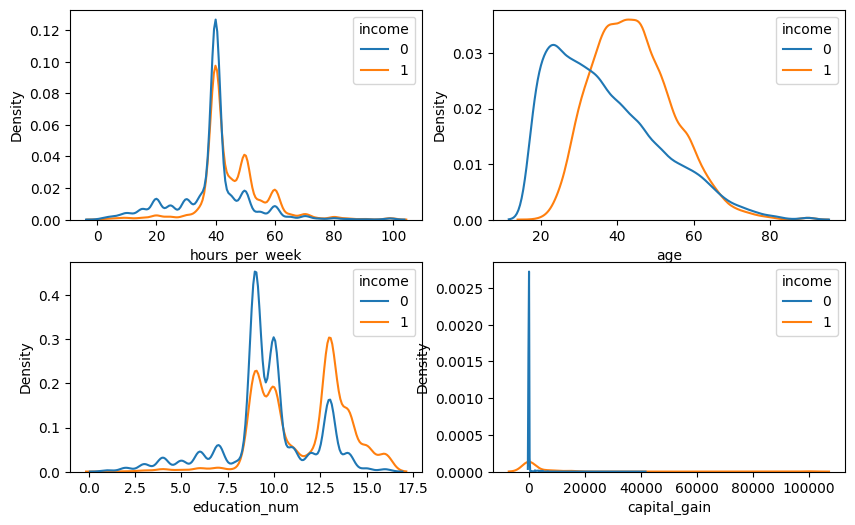

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
sns.kdeplot(
    x="hours_per_week", hue="income", data=df_train, ax=axs[0, 0], common_norm=False
)
sns.kdeplot(x="age", hue="income", data=df_train, ax=axs[0, 1], common_norm=False)
sns.kdeplot(
    x="education_num", hue="income", data=df_train, ax=axs[1, 0], common_norm=False
)
sns.kdeplot(
    x="capital_gain", hue="income", data=df_train, ax=axs[1, 1], common_norm=False
)

For the capital gain variable it seems that for most survey participants the value is 0.

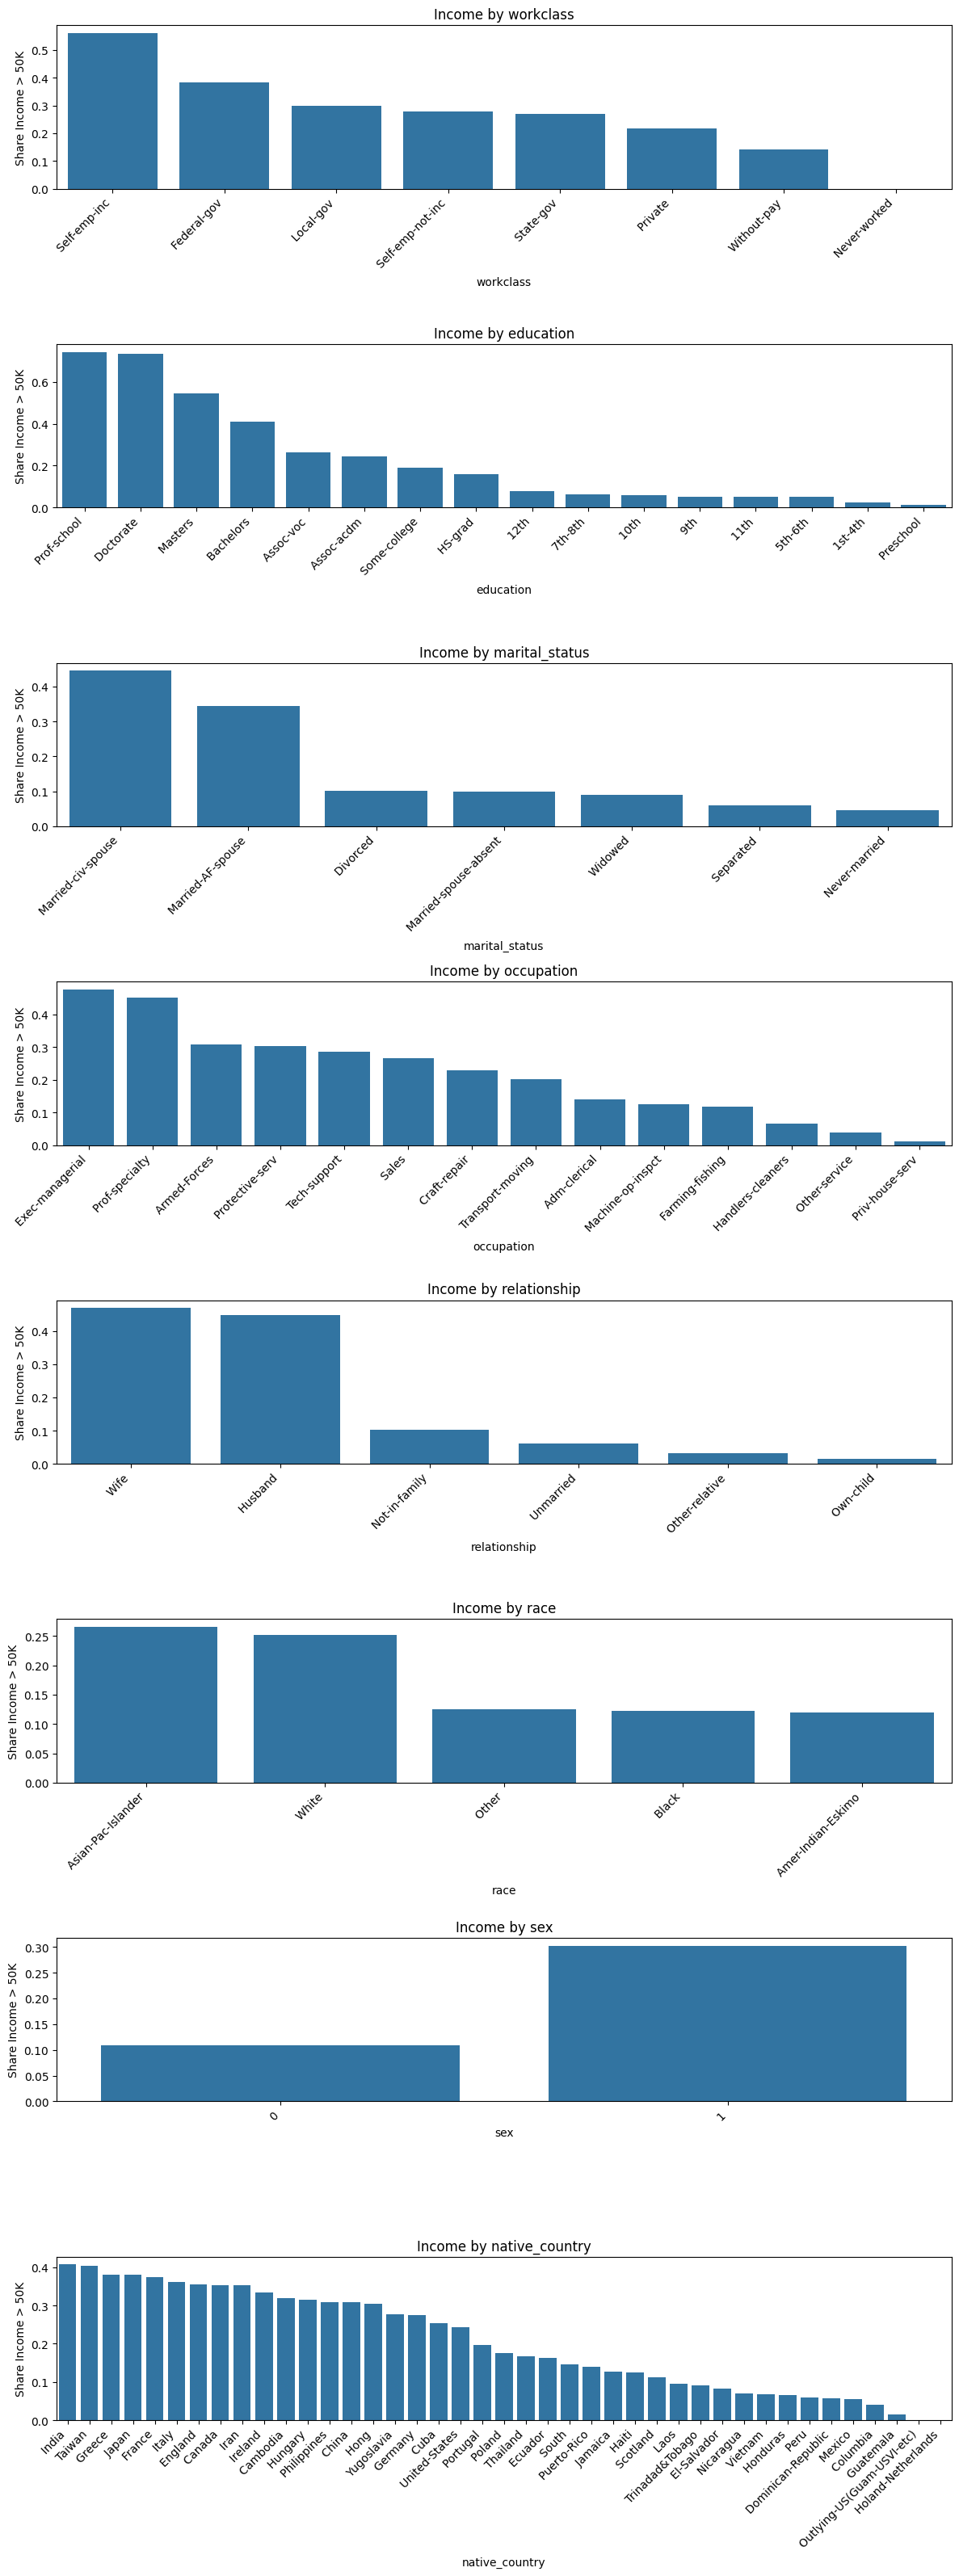

In [9]:
categorical_cols = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country",
]

fig, axs = plt.subplots(
    len(categorical_cols), 1, figsize=(12, 4 * len(categorical_cols))
)

for i, col in enumerate(categorical_cols):
    mean_income = df_train.groupby(col)["income"].mean().sort_values(ascending=False)
    sns.barplot(x=mean_income.index, y=mean_income.values, ax=axs[i])
    axs[i].set_title(f"Income by {col}")
    axs[i].set_ylabel("Share Income > 50K")
    plt.setp(axs[i].xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

That's enough plotting for now. It seems that most variables in the dataset are correlated with the target variable.

## Cross-validation

Until this lecture we used to have a fixed validation set - a dataset using which we decide which of the many models that we fit in a single notebook is the best one. However, a fixed validation set has the disadvantage that just by accident during sampling we might get data that is not representative of the whole dataset.

A superior approach is k-fold cross validation, during which we split our training data into k folds and then train the model k times, each time training and evaluating on a different set of data, like illustrated in the image below.



![K-Fold Cross Validation](../../assets/kfold_cross_validation.png)



### Task


Fit a K-Nearest-Neighbor classifier for predicting `income` using `hours_per_week` and `education_num` variables. Use n_neighbors=5. Do not evaluate the model yet.


In [10]:
from sklearn.neighbors import KNeighborsClassifier

X_train_hours_edu = df_train[["hours_per_week", "education_num"]]
y_train = df_train["income"]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_hours_edu, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


How can we evaluate this model? We don't have a validation set...

We can modify the code above to apply K-fold cross-validation.


In [11]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

kf = KFold(n_splits=5, shuffle=True, random_state=10)
scores = []

for train_index, test_index in kf.split(X_train_hours_edu):
    X_train_fold = X_train_hours_edu.iloc[train_index]
    X_val_fold = X_train_hours_edu.iloc[test_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[test_index]

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_fold, y_train_fold)

    score = knn.predict_proba(X_val_fold)[:, 1]
    pred = score > 0.5
    scores.append(f1_score(y_val_fold, pred))

print(scores)
np.mean(scores)

[0.40181268882175225, 0.42257597684515197, 0.4172225591267435, 0.4540150041678244, 0.42532005689900426]


np.float64(0.4241892571720952)

K-fold cross validation happens to be a more robust model validation method than fixed-set validation, because we're fitting and evaluating the model K times, instead of a single time on one dataset.


However, there's a problem with our metric - F1 score depends on the threshold, and in our case 0.5 happens to be not the most optimal threshold (you can see that by trying several thresholds above). We would like to leave threshold tuning as the last step in our modelling, which means we have to find a metric that does not depend on a specific threshold, in other words a metric that is capable of evaluation the probability distribution that the model outputs. One of such metrics is area under the ROC curve, commonly abbreviated as ROC AUC.

Here's how the ROC curve is built:
1. Make predictions
2. Loop through all possible thresholds (0.01...0.99 in increments of 0.01)
    1. For each threshold, apply the threshold to probabilities to get binary predictions
    2. calculate two classification metrics - true positive rate (TPR, aka recall) and false positive rate (FPR)
3. plot TPR against FPR on a lineplot
4. Calculate area under the curve. the closer the area is to 1, the better

For historical reasons this metric is called receiver operating characteristic area under the curve (ROC AUC).

The code below shows how the ROC curve is constructed. It uses training data for this, but this is only done for illustration. We calculate ROC AUC on the validation set during cross validation.


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Fit a single model on the entire training data
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_train_hours_edu, y_train)
y_scores = knn.predict_proba(X_train_hours_edu)[:, 1]

thresholds = np.linspace(0, 1, 100)
metrics = []

for threshold in thresholds:
    y_pred = y_scores >= threshold
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
    tpr = tp / (tp + fn)  # true positive rate, aka recall
    fpr = fp / (fp + tn)  # false positive rate
    metrics.append(
        {
            "threshold": threshold,
            "tpr": tpr,
            "fpr": fpr
        }
    )
metrics_df = pd.DataFrame(metrics)

In [13]:
metrics_df

,threshold,tpr,fpr
0,0.000000,1.000000,1.000000
1,0.010101,0.997097,0.945351
2,0.020202,0.991076,0.886638
3,0.030303,0.991076,0.886638
4,0.040404,0.982690,0.816035
...,...,...,...
95,0.959596,0.000000,0.000000
96,0.969697,0.000000,0.000000
97,0.979798,0.000000,0.000000
98,0.989899,0.000000,0.000000


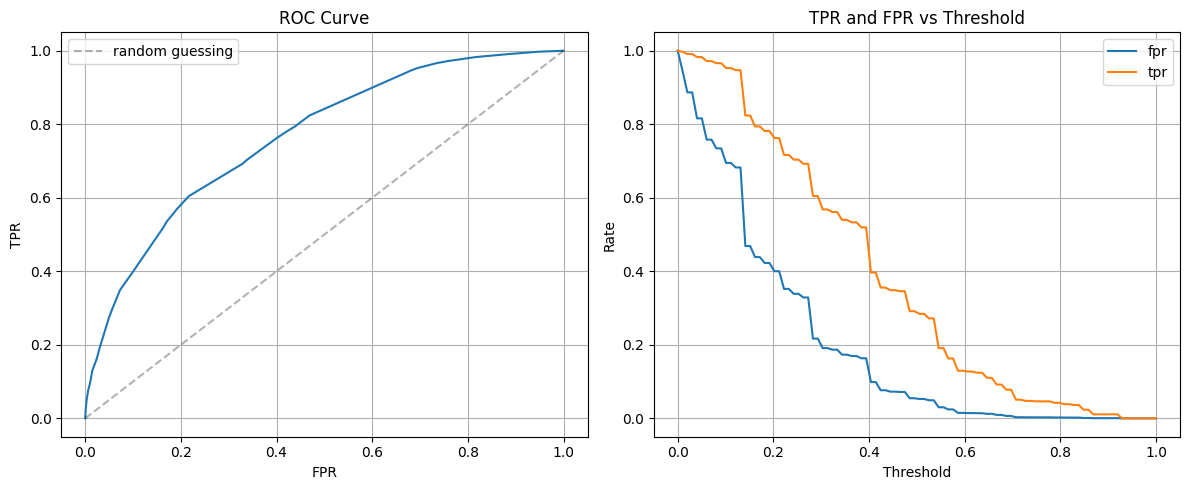

In [14]:

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot ROC curve on the first subplot
ax1.plot(metrics_df["fpr"], metrics_df["tpr"])
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3, label="random guessing")
ax1.set_xlabel("FPR")
ax1.set_ylabel("TPR")
ax1.set_title("ROC Curve")
ax1.grid(True)
ax1.legend()

# Plot TPR and FPR vs threshold on the second subplot
sns.lineplot(data=metrics_df, x="threshold", y="fpr", ax=ax2, label="fpr")
sns.lineplot(data=metrics_df, x="threshold", y="tpr", ax=ax2, label="tpr")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Rate")
ax2.set_title("TPR and FPR vs Threshold")
ax2.grid(True)

plt.tight_layout()


As always, we don't have to write these calculations ourselves, scikit-learn provides the metric function.

In [15]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train, y_scores)


0.764841335886602

We can now use this metric in cross validation. However, for cross validation, we do not have to write the whole for loop like before, since scikit-learn provides a convenient wrapper.



In [ ]:
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(
    knn, X_train_hours_edu, y_train, cv=5, scoring="roc_auc"
)  # cv=kf also possible
np.mean(scores)

np.float64(0.6930597438823016)

And that's k-fold cross validation (sometimes referred to as just cross-validation, since the k-fold version is by far the most popular). 


## Regularization

### Task

Fit a simple logistic regression model on X_train_hours_edu. Do not apply any regularization (penalty=None) Evaluate it using k-fold cross validation with 5 folds and roc_auc as the metric. 


In [17]:
from sklearn.linear_model import LogisticRegression

model_logreg = LogisticRegression(penalty=None)
scores = cross_val_score(
    model_logreg, X_train_hours_edu, y_train, cv=5, scoring="roc_auc"
)
np.mean(scores)

np.float64(0.7594505621289634)

Now let's talk about that penalty parameter. Whenever we train a model our goal is to find optimal model parameters (also called weights or coefficients). A simple linear or logistic regression with one feature would have two parameters (intercept and slope). Regularization allows us to control how large these parameters are allowed to grow, and therefore allows us to control the complexity of the model, since a model with large parameters is more likely to overfit to the noise in the data.

Penalty allows us to set two kinds of regularization - L1 or L2 (or both, but we'll stick to either L1 or L2 in this course). Sometimes these are called Lasso and Ridge regression. 

L1 penalty adds the sum of absolute values of coefficients to the loss function:

$$Loss_{L1} = Loss_{original} + \frac{1}{C} \sum_{i=1}^{n} |w_i|$$

This incentivizes the model to reduce the size of the coefficients. The parameter $C$ controls the strength of regularization - lower $C$ means stronger regularization.


In [18]:
model_logreg = LogisticRegression(
    penalty="l1", C=0.00001, solver="liblinear"
)  # play around with C to see how it affects the coefficients
model_logreg.fit(X_train_hours_edu, y_train)
print(model_logreg.coef_)
print(model_logreg.intercept_)

[[-0.01608047  0.        ]]
[0.]


Low C means more regularization. More regularization means lower model coefficients. Lower coefficients (also known as model weights) means lower model complexity, lower likelihood of overfitting. 

L2 regularization uses the sum of squared coefficients instead:

$$Loss_{L2} = Loss_{original} + \frac{1}{C} \sum_{i=1}^{n} w_i^2$$

You'll notice that with L2 regularization, coefficients decrease, but never reach 0. L1 regularization can get our coefficients exactly to 0.


In [19]:
model_logreg = LogisticRegression(
    penalty="l2", C=0.000001
)  # play around with C to see how it affects the coefficients
model_logreg.fit(X_train_hours_edu, y_train)
print(model_logreg.coef_)
print(model_logreg.intercept_)


[[0.02227457 0.01296078]]
[-2.21444123]


We can also observe what regularization does to the decision boundary that a logistic regression model produces.

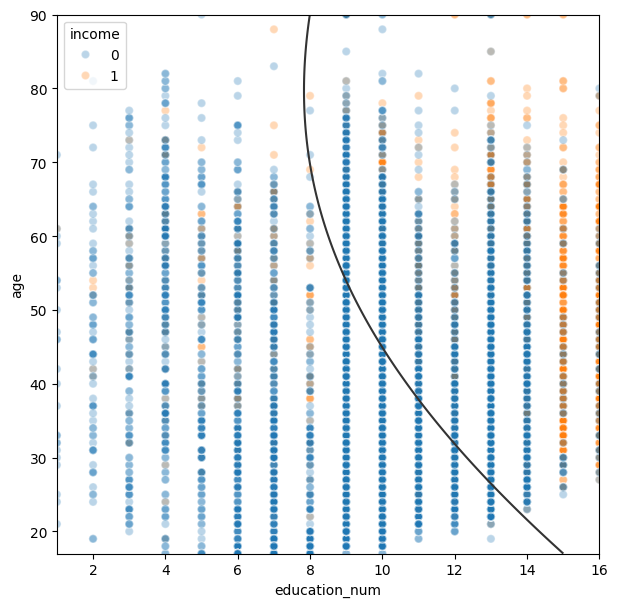

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

# Downsample majority class for cleaner visualization
df_train_pos = df_train[df_train["income"] == 1]
df_train_neg = df_train[df_train["income"] == 0].sample(n=len(df_train_pos), random_state=42)
df_train_balanced = pd.concat([df_train_pos, df_train_neg])

X_train_age_edu = df_train_balanced[["education_num", "age"]]
y_train_balanced = df_train_balanced["income"]

model = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(penalty="l2", C=0.001, max_iter=5000)),
])
model.fit(X_train_age_edu, y_train_balanced)
plot_decision_boundary(df_train_balanced["education_num"], df_train_balanced["age"], y_train_balanced, model)


And that's regularization! It's a way to prevent overfitting by reducing model's weights.

However, it can also result in underfitting if we reduce the weights too much. That's why we have to find the optimal regularization strength via hyperparameter tuning.

## Hyperparameter Tuning

But what is optimal C? We've been playing around with different values for it, but what should we set it to? In other words - how much regularization should be applied?

We can get an answer to this question by performing hyperparameter tuning.


In [48]:
C_values = [10**i for i in range(-5, 5)]  # Goes from 10^-5 to 10^4
summary = []

for C in C_values:
    model_logreg = LogisticRegression(penalty="l1", C=C, solver="liblinear")
    scores = cross_val_score(
        model_logreg, X_train_hours_edu, y_train, cv=5, scoring="roc_auc"
    )
    summary.append(
        {
            "C": C,
            "cv_score": np.mean(scores),
        }
    )

summary_df = pd.DataFrame(summary)

In [49]:
summary_df.style.highlight_max(subset=["cv_score"], color="blue")

,C,cv_score
0,0.000010,0.328093
1,0.000100,0.328093
2,0.001000,0.532320
3,0.010000,0.759500
4,0.100000,0.759413
5,1.000000,0.759388
6,10.000000,0.759527
7,100.000000,0.759534
8,1000.000000,0.759362
9,10000.000000,0.759429


The most optimal C (in terms of ROC AUC score) is 0.01.

### Task

Fit a logistic regression model with polynomial features of degree=2 and scaling. Use scikit-learn pipelines. Validate the model using cross-validation, use roc_auc as a metric.


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

poly_logreg = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(penalty="l1", C=0.1, max_iter=5000, solver="liblinear"),
        ),
    ]
)

scores = cross_val_score(
    poly_logreg, X_train_hours_edu, y_train, cv=5, scoring="roc_auc"
)

np.mean(scores)

np.float64(0.7618159726066862)

### Task

Modify your code below to find optimal C and PolynomialFeatures degree.


In [ ]:
from itertools import product

C_values = [10**i for i in range(-3, 3)]
degree_values = [1, 2]

summary = []

for C, degree in product(C_values, degree_values):
    # implement
    pass

In [43]:
from itertools import product

C_values = [10**i for i in range(-3, 3)]
degree_values = [1, 2]
# class_weight_values = [None, "balanced"]

summary = []

for C, degree in product(C_values, degree_values):
    poly_logreg = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree)),
            ("scaler", StandardScaler()),
            (
                "logreg",
                LogisticRegression(
                    penalty="l1",
                    C=C,
                    max_iter=5000,
                    solver="liblinear",
                ),
            ),
        ]
    )

    scores = cross_val_score(
        poly_logreg, X_train_hours_edu, y_train, cv=5, scoring="roc_auc"
    )

    summary.append(
        {
            "C": C,
            "degree": degree,
            "cv_score": np.mean(scores),
        }
    )

In [44]:
pd.DataFrame(summary).style.highlight_max(subset=["cv_score"], color="yellow")

,C,degree,cv_score
0,0.001000,1,0.756370
1,0.001000,2,0.759501
2,0.010000,1,0.759482
3,0.010000,2,0.760839
4,0.100000,1,0.759459
5,0.100000,2,0.761816
6,1.000000,1,0.759460
7,1.000000,2,0.762071
8,10.000000,1,0.759460
9,10.000000,2,0.762081


What we've done right now is called hyperparameter tuning - we created a bunch of models, trained and validated each, while only changing the hyperparameters of those models, in this case regularization and polynomial features degree.

What we can still do is simplify the whole procedure by utilizing GridSearchCV, which does exactly what we did in the for loop above.


In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [10**i for i in range(-5, 5)],
}
logreg = LogisticRegression(penalty="l1", solver="liblinear")

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring="roc_auc")
grid_search.fit(X_train_hours_edu, y_train)

print(grid_search.best_params_)
print(round(grid_search.best_score_, 4))

{'C': 0.1}
0.7595


### Task

Adjust the code above to find out which class_weight parameter performs better, `"balanced"` or `None` (in conjunction with the `C` parameter).


In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [10**i for i in range(-6, 5)], "class_weight": [None, "balanced"]}
logreg = LogisticRegression(penalty="l1", solver="liblinear")

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring="roc_auc")
grid_search.fit(X_train_hours_edu, y_train)

print(grid_search.best_params_)
print(round(grid_search.best_score_, 4))

{'C': 100, 'class_weight': None}
0.7595


### Task

Perform hyperparameter search on a k-nearest-neighbor model over `n_neighbors` and `weights` parameters. `n_neighbors` should be a list of values between 3 and 15, and `weights` can be `"uniform"` or `"distance"`. Use GridSearchCV.


In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for KNN
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15],  # increase upper limit
    "weights": ["uniform", "distance"],
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring="roc_auc")
grid_search.fit(X_train_hours_edu, y_train)

print(grid_search.best_params_)
print(round(grid_search.best_score_, 4))

{'n_neighbors': 15, 'weights': 'uniform'}
0.7348


Ok, so we now have a process for setting optimal hyperparameters. But what about hyperparameter ranges? How can we know what they should be set to?

A good process is to simply adjust the ranges iteratively. If you run hyperparameter tuning and see that the most optimal parameters are at the top of some range for a specific parameter, it's probably a good idea to increase the range for that parameter.


## Missing values

Most algorithms don't work when missing values are present in the data. We have quite a few rows with missing data, and e.g. logistic regression will throw an error if it encounters missing values.

In [30]:
# Count rows with at least one missing value
df_train.isna().any(axis=1).sum()

np.int64(2909)

Imputing missing values for categorical features is relatively simple - just treat the missing values as a separate category.

In [31]:
df_train.value_counts("workclass", dropna=False)

workclass
 Private             27235
 Self-emp-not-inc     3081
 Local-gov            2487
NaN                   2255
 State-gov            1550
 Self-emp-inc         1310
 Federal-gov          1133
 Without-pay            14
 Never-worked            8
Name: count, dtype: int64

In [32]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Now we can use the imputer if needed for other missing values
missing_imputer = SimpleImputer(strategy="constant", fill_value="missing")
workclass_imputed = missing_imputer.fit_transform(df_train[["workclass"]])
pd.DataFrame(workclass_imputed).value_counts()

0                
 Private             27235
 Self-emp-not-inc     3081
 Local-gov            2487
missing               2255
 State-gov            1550
 Self-emp-inc         1310
 Federal-gov          1133
 Without-pay            14
 Never-worked            8
Name: count, dtype: int64

In [33]:

# One-hot encode the imputed data
encoder = OneHotEncoder(drop="first")
workclass_encoded = encoder.fit_transform(workclass_imputed)

# continue with modelling

How can we impute continuous columns?

In [34]:
feature = np.random.uniform(size=100)
feature[:20] = np.nan

tmp = pd.DataFrame(feature, columns=["a"])

In [35]:
tmp

,a
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
95,0.148425
96,0.315099
97,0.257184
98,0.878817


In [36]:
mean_imputer = SimpleImputer(strategy="median")
mean_imputer.fit_transform(tmp)

array([[0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.46262018],
       [0.68329138],
       [0.11873477],
       [0.80376252],
       [0.37175727],
       [0.32986526],
       [0.02464197],
       [0.29862362],
       [0.63175725],
       [0.56856513],
       [0.70724287],
       [0.14823358],
       [0.13040348],
       [0.26522461],
       [0.33066495],
       [0.86379157],
       [0.37575448],
       [0.80287732],
       [0.87855737],
       [0.35958209],
       [0.41918688],
       [0.83339718],
       [0.30128582],
       [0.54170008],
       [0.66675441],
       [0.37461001],
       [0.6683315 ],
       [0.79817895],
       [0.948

### Task

Fit a LogisticRegression model for predicting `income` using these features:
- `workclass`
- `hours_per_week`
- `relationship`
- `age`

To categorical variables, apply missing value imputation (strategy `constant`) and onehot-encoding. To continuous variables, apply second-degree polynomial transformations and standard scaling.

Set penalty in LogisticRegression to "l2", leave default C (tuning it is the next task).

Use ColumnTransformer from last week to select which features to apply the transformations to.


In [ ]:
# hint
from sklearn.compose import ColumnTransformer

X_train = ...

categorical_transformer = Pipeline(steps=[("imputer", ...), ("onehot", ...)])

numerical_transformer = Pipeline(steps=[...])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, [...]),
        ("num", numerical_transformer, [...]),
    ]
)

model = Pipeline(
    steps=[("preprocessor", preprocessor), ("logreg", LogisticRegression())]
)

# fit the model

In [38]:
from sklearn.compose import ColumnTransformer

X_train = df_train[["workclass", "hours_per_week", "relationship", "age"]]

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numerical_transformer = Pipeline(
    steps=[("poly", PolynomialFeatures(degree=2)), ("scaler", StandardScaler())]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, ["workclass", "relationship"]),
        ("num", numerical_transformer, ["hours_per_week", "age"]),
    ]
)

model = Pipeline(
    steps=[("preprocessor", preprocessor), ("logreg", LogisticRegression(penalty="l2"))]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

### Task

Find the most optimal value for C value using the model defined in the previous task. Apply GridSearchCV.


In [39]:
# Hint

param_grid = {
    "logreg__C": [10**i for i in range(-5, 5)],
}

# perform GridSearchCV

In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "logreg__C": [10**i for i in range(-5, 5)],
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="roc_auc",
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

{'logreg__C': 10}

In [41]:
grid_search.best_score_

np.float64(0.8409904363758669)